# **Imports & Setup**

In [7]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    classification_report, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from statsmodels.tsa.statespace.sarimax import SARIMAX
from joblib import Parallel, delayed
from scipy.stats import wilcoxon
import shap
import matplotlib.pyplot as plt

# **Data Loading & Preprocessing**

In [8]:
df = pd.read_csv('/content/raw_weekly_hospital_respiratory_data_2020_2024.csv')

keep_cols = [
    'Geographic aggregation', 'Week Ending Date',
    'Percent Inpatient Beds Occupied', 'Percent ICU Beds Occupied',
    'Total Patients Hospitalized with COVID-19',
    'Total Patients Hospitalized with Influenza',
    'Total Patients Hospitalized with RSV'
]

df = df[keep_cols].copy()
df.columns = ['Region','Week','Pct_Inpatient','Pct_ICU','COVID','Influenza','RSV']
df['Week'] = pd.to_datetime(df['Week'])
df = df.sort_values(['Region','Week']).reset_index(drop=True)

# Imputation: Forward-fill within region first, then fall back to regional median
df[['Pct_Inpatient','Pct_ICU','COVID','Influenza','RSV']] = (
    df.groupby('Region')[['Pct_Inpatient','Pct_ICU','COVID','Influenza','RSV']].ffill()
)

for col in ['Pct_Inpatient','Pct_ICU','COVID','Influenza','RSV']:
    df[col] = df.groupby('Region')[col].transform(
        lambda x: x.fillna(x.median())
    )

df = df.dropna(subset=['Pct_Inpatient']).reset_index(drop=True)
print(f'After preprocessing: {df.shape}')

After preprocessing: (12768, 7)


# **Feature Engineering**

In [9]:
# Lag features for disease burden and ICU (1 week lag)
for col in ['COVID','Influenza','RSV','Pct_ICU']:
    df[f'{col}_lag1'] = df.groupby('Region')[col].shift(1)

# Lag features for inpatient occupancy (target)
for lag in [1, 2, 4, 52]:
    df[f'Lag_{lag}'] = df.groupby('Region')['Pct_Inpatient'].shift(lag)

# Seasonality features
df['Week_of_Year'] = df['Week'].dt.isocalendar().week.astype(float)
df['Flu_Season'] = df['Week_of_Year'].apply(
    lambda w: 1 if (w >= 40 or w <= 12) else 0).astype(float)

# Surge label: >= 85% inpatient occupancy
SURGE_THRESHOLD = 0.85
df['Surge'] = (df['Pct_Inpatient'] >= SURGE_THRESHOLD).astype(int)

df = df.dropna().reset_index(drop=True)

features = [
    'Lag_1','Lag_2','Lag_4','Lag_52',
    'Week_of_Year','Flu_Season',
    'Pct_ICU_lag1','COVID_lag1','Influenza_lag1','RSV_lag1'
]

print(f'Shape: {df.shape}  Surge rate: {df["Surge"].mean():.1%}')

Shape: (9632, 18)  Surge rate: 7.5%


# **Train / Test Split**

In [10]:
SPLIT_DATE = '2023-08-01'

# Temporal split — no shuffling. All weeks before Aug 2023 are training data.
train = df[df['Week'] < SPLIT_DATE].copy()
test  = df[df['Week'] >= SPLIT_DATE].copy()

X_train, y_train = train[features], train['Surge']
X_test,  y_test  = test[features],  test['Surge']

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Surge  train={y_train.mean():.1%}  test={y_test.mean():.1%}')
print(f'Imbalance ratio: {scale_pos:.1f}')

Train: (5824, 10)  Test: (3808, 10)
Surge  train=6.2%  test=9.4%
Imbalance ratio: 15.2


# **SARIMA — Per-Region Fit & Reliability Filter**

In [11]:
def fit_region_sarima(region, df, split_date):
    split_ts  = pd.Timestamp(split_date)
    region_df = df[df['Region'] == region].set_index('Week').sort_index()
    s_train   = region_df[region_df.index < split_ts]['Pct_Inpatient']
    s_test    = region_df[region_df.index >= split_ts]['Pct_Inpatient']
    std = s_train.std()

    configs = []
    if std >= 0.04:
        configs.append(((1,1,1),(1,1,1,52)))
    configs.append(((1,0,1),(0,0,0,0)))

    for order, seasonal_order in configs:
        try:
            fit = SARIMAX(s_train, order=order, seasonal_order=seasonal_order,
                          enforce_stationarity=False, enforce_invertibility=False
                          ).fit(disp=False, method='powell', maxiter=50)
            fc    = fit.get_forecast(steps=len(s_test))
            preds = fc.predicted_mean
            ci    = fc.conf_int()

            if preds.isna().any() or (preds.abs() > 1.5).any(): continue

            from sklearn.metrics import mean_squared_error, mean_absolute_error
            rmse = np.sqrt(mean_squared_error(s_test, preds))
            mae  = mean_absolute_error(s_test, preds)
            if rmse > 0.15: continue

            fitted   = fit.fittedvalues.dropna()
            roll_std = (s_train.rolling(4, min_periods=1).std()
                        .fillna(std).reindex(fitted.index).fillna(std))

            train_r = pd.DataFrame({
                'Region': region, 'Week': fitted.index.tolist(),
                'SARIMA_forecast': fitted.values,
                'SARIMA_upper':   (fitted + 1.96*roll_std).values,
                'SARIMA_RMSE': rmse, 'SARIMA_MAE': mae})

            test_r = pd.DataFrame({
                'Region': region, 'Week': s_test.index.tolist(),
                'SARIMA_forecast': preds.values,
                'SARIMA_upper':    ci.iloc[:,1].values,
                'SARIMA_RMSE': rmse, 'SARIMA_MAE': mae})

            if len(train_r) == 0 or len(test_r) == 0: continue
            return pd.concat([train_r, test_r], ignore_index=True)

        except: continue

    print(f'  {region}: all configs failed')
    return None

regions = df['Region'].unique().tolist()

results = Parallel(n_jobs=-1, backend='loky')(
    delayed(fit_region_sarima)(r, df, SPLIT_DATE) for r in regions
)

sarima_df = pd.concat([r for r in results if r is not None], ignore_index=True)

print(f'SARIMA fitted for {sarima_df["Region"].nunique()} regions')
print(sarima_df.groupby('Region')[['SARIMA_RMSE','SARIMA_MAE']].first()
      .agg(['mean','min','max']).round(4))

df = df.merge(
    sarima_df[['Region','Week','SARIMA_forecast','SARIMA_upper']],
    on=['Region','Week'], how='left'
)

# 4.3 Reliability Filter (corr >= 0.3)
test_sarima = df[df['Week'] >= SPLIT_DATE].dropna(subset=['SARIMA_forecast'])

corr_by_region = (
    test_sarima.groupby('Region')
    .apply(lambda g: g['SARIMA_forecast'].corr(g['Pct_Inpatient']))
    .dropna().sort_values()
)

print(corr_by_region.describe().round(3))
reliable_regions = corr_by_region[corr_by_region >= 0.3].index.tolist()
print(f'Reliable: {len(reliable_regions)}/53')

# Create clean SARIMA columns — NaN for unreliable regions
for col in ['SARIMA_forecast','SARIMA_upper']:
    df[f'{col}_clean'] = df.apply(
        lambda row: row[col] if row['Region'] in reliable_regions else np.nan,
        axis=1
    )

SARIMA fitted for 53 regions
      SARIMA_RMSE  SARIMA_MAE
mean       0.0566      0.0429
min        0.0164      0.0133
max        0.1268      0.0894
count    53.000
mean      0.126
std       0.414
min      -0.761
25%      -0.252
50%       0.200
75%       0.438
max       0.782
dtype: float64
Reliable: 24/53


# **Model Training & Evaluation**

In [12]:
features_base = features  # 10 lag/seasonal features, all 56 regions

hybrid_features_forecast = features + ['SARIMA_forecast_clean']
hybrid_features_upper    = features + ['SARIMA_forecast_clean', 'SARIMA_upper_clean']

# Hybrid subsets — only rows where SARIMA features are available
train_h = df[(df['Week'] < SPLIT_DATE) & df['SARIMA_forecast_clean'].notna()].copy()
test_h  = df[(df['Week'] >= SPLIT_DATE) & df['SARIMA_forecast_clean'].notna()].copy()

X_train_h = train_h[hybrid_features_upper]
y_train_h = train_h['Surge']
X_test_h  = test_h[hybrid_features_upper]
y_test_h  = test_h['Surge']

print(f'Base   — train: {X_train.shape}  test: {X_test.shape}')
print(f'Hybrid — train: {X_train_h.shape}  test: {X_test_h.shape}')
print(f'Hybrid surge  train={y_train_h.mean():.1%}  test={y_test_h.mean():.1%}')

def eval_classifier(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1]
    f1   = f1_score(y_te, y_pred)
    roc  = roc_auc_score(y_te, y_prob)
    pr   = average_precision_score(y_te, y_prob)
    print(f'{name:<40} F1={f1:.3f}  ROC={roc:.3f}  PR-AUC={pr:.3f}')
    return model, y_prob

print('--- Base models (56 regions) ---')
lr, lr_prob = eval_classifier('Logistic Regression',
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    X_train, y_train, X_test, y_test)

rf, rf_prob = eval_classifier('Random Forest',
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    X_train, y_train, X_test, y_test)

print('\n--- Hybrid models (22 reliable regions) ---')
rf_h_fc, rf_h_fc_prob = eval_classifier('RF Hybrid — forecast only',
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    train_h[hybrid_features_forecast], y_train_h,
    test_h[hybrid_features_forecast],  y_test_h)

rf_h_up, rf_h_up_prob = eval_classifier('RF Hybrid — forecast + upper bound',
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    X_train_h, y_train_h, X_test_h, y_test_h)

Base   — train: (5824, 10)  test: (3808, 10)
Hybrid — train: (2496, 12)  test: (1632, 12)
Hybrid surge  train=5.3%  test=9.5%
--- Base models (56 regions) ---
Logistic Regression                      F1=0.714  ROC=0.973  PR-AUC=0.854
Random Forest                            F1=0.853  ROC=0.979  PR-AUC=0.911

--- Hybrid models (22 reliable regions) ---
RF Hybrid — forecast only                F1=0.866  ROC=0.992  PR-AUC=0.913
RF Hybrid — forecast + upper bound       F1=0.882  ROC=0.987  PR-AUC=0.901


# **Threshold Optimisation & Calibration**

Optimal threshold (F2): 0.130
  Precision : 0.683
  Recall    : 0.942
  F2-score  : 0.875
ECE — RF (uncalibrated): 0.0085


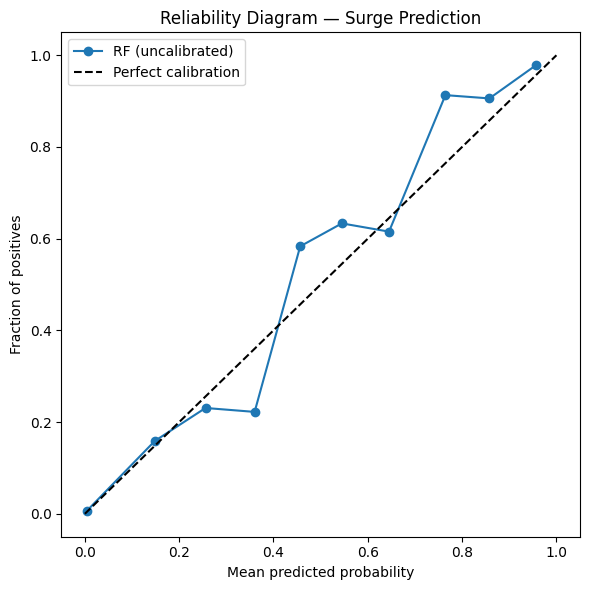

In [13]:
from sklearn.metrics import mean_squared_error

# F2-optimal threshold
precision, recall, thresholds = precision_recall_curve(y_test, rf_prob)
beta = 2
fbeta = ((1 + beta**2) * precision * recall /
         (beta**2 * precision + recall + 1e-9))

best_idx       = np.argmax(fbeta)
best_threshold = thresholds[best_idx]

print(f'Optimal threshold (F2): {best_threshold:.3f}')
print(f'  Precision : {precision[best_idx]:.3f}')
print(f'  Recall    : {recall[best_idx]:.3f}')
print(f'  F2-score  : {fbeta[best_idx]:.3f}')

# Calibration — Expected Calibration Error
def ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece_val = 0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0: continue
        ece_val += mask.sum() * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece_val / len(y_true)

print(f'ECE — RF (uncalibrated): {ece(y_test.values, rf_prob):.4f}')

# Reliability diagram
fig, ax = plt.subplots(figsize=(6, 6))
frac_pos, mean_pred = calibration_curve(y_test, rf_prob, n_bins=10)
ax.plot(mean_pred, frac_pos, marker='o', label='RF (uncalibrated)')
ax.plot([0,1],[0,1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Reliability Diagram — Surge Prediction')
ax.legend()
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()